# Topology identification via the generalized Sylvester equation
### van Waarde, Tesi & Camlibel (2020), *Automatica* — applied to the grid impulse tensor

This notebook implements the **topology-identification** algorithm from `network dynamic paper.pdf` and tests whether it fits our photostim-grid data.

**Why it's relevant.** The paper reconstructs a network's *coupling matrix* `Q` (the graph) from the network's **Markov parameters** — and our grid impulse-response tensor `H[s,r,t]` *is* exactly a set of Markov parameters (the Green's function from stim `s` to readout `r` at lag `t`). So the required input is already in hand.

**The catch (why it's a cross-check, not a drop-in).** The method assumes the **node dynamics are known** `(A_i,B_i,C_i)` and only solves for the coupling `Q`; and exact recovery needs `r ≥ 2n−1` Markov lags (`n` = total state dim). Our nodes' dynamics are unknown (entangled with coupling) and we have ~36 usable lags, not the 207 a 2nd-order-node model would demand. So on real data it is underdetermined and needs regularization — the opposite regime from our graph-wave fit, which *jointly* learns node dynamics + coupling. We therefore use it as a **validated reference (exact on synthetic data)** and a **corroborating cross-check** on locality.

## The model & algorithm

**Network** (discrete time). Node `i` is a linear system `(A_i,B_i,C_i)`; nodes are coupled through an interconnection matrix `Q`:
$$x(t{+}1) = (A + BQC)\,x(t) + BR\,u(t),\qquad y(t) = SC\,x(t)$$
with `A,B,C` block-diagonal over nodes. `Q` is the **weighted graph** to recover (`Q_{ij}` = coupling `j→i`). Take `S=I`, `R=I`.

**Markov parameters** of the closed loop: `M_ℓ = C (A+BQC)^ℓ B R`. Lemma 9 of the paper makes each `M_ℓ` *affine* in `Q`; stacking `ℓ=1..r` gives the **generalized Sylvester equation**
$$K = \sum_{i=0}^{r-1} L_i\,Q\,M_i,\qquad K_ℓ := M_ℓ - C A^ℓ B R,$$
where `L` is the lower-triangular Toeplitz matrix of the *open-loop* node Markov parameters `C A^k B`. Vectorizing: $\big(\sum_i M_i^\top \otimes L_i\big)\,\mathrm{vec}(Q) = \mathrm{vec}(K)$ — a **linear** system for `Q` (closed-form, no nonconvex optimization). Under identifiability + `r ≥ 2n−1`, the solution is unique (Theorem 10).

## Core implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True)

def homog_network(A0, B0, C0, Q):
    """Homogeneous network: every node is (A0,B0,C0); coupling Q (NxN); R=I. Returns A,B,C,Acl."""
    N = Q.shape[0]
    A = np.kron(np.eye(N), A0); B = np.kron(np.eye(N), B0); C = np.kron(np.eye(N), C0)
    return A, B, C, A + B @ Q @ C                       # A+BQC (R=I => BR=B)

def markov_params(A, B, C, Acl, r):
    """Closed-loop M_l = C Acl^l B and open-loop C A^l B, l=0..r (each NxN)."""
    n = A.shape[0]; M, CAlB = [], []; Pcl = np.eye(n); Pol = np.eye(n)
    for _ in range(r + 1):
        M.append(C @ Pcl @ B); CAlB.append(C @ Pol @ B); Pcl = Acl @ Pcl; Pol = A @ Pol
    return M, CAlB

def reconstruct_Q(M, CAlB, N, r, ridge=0.0):
    """Solve the generalized Sylvester equation K = sum_i L_i Q M_i for Q (optionally ridged)."""
    K = [M[l] - CAlB[l] for l in range(1, r + 1)]        # K_1..K_r
    b = np.vstack(K).reshape(-1, order='F')              # vec(col(K_1..K_r))
    Li = []
    for i in range(r):                                   # L_i = (i+1)-th column block of Toeplitz(CA^kB)
        Lb = np.zeros((r * N, N))
        for a in range(i, r):
            Lb[a * N:(a + 1) * N, :] = CAlB[a - i]
        Li.append(Lb)
    Phi = sum(np.kron(M[i].T, Li[i]) for i in range(r))  # (rN*N) x (N*N)
    if ridge > 0:
        q = np.linalg.solve(Phi.T @ Phi + ridge * np.eye(Phi.shape[1]), Phi.T @ b)
    else:
        q = np.linalg.lstsq(Phi, b, rcond=None)[0]
    return q.reshape(N, N, order='F')

## 1 · Validation on synthetic data — exact recovery

Build a small network with a **known** coupling `Q` and known 2nd-order (damped-oscillator) nodes, generate its Markov parameters, and reconstruct. With `r ≥ 2n−1` exact lags the recovery is exact (error at machine precision) — this confirms the implementation and our reading of the algorithm.

closed-loop spectral radius: 0.981
reconstruction error ||Q_hat - Q||_F / ||Q||_F = 7.187351360860616e-16


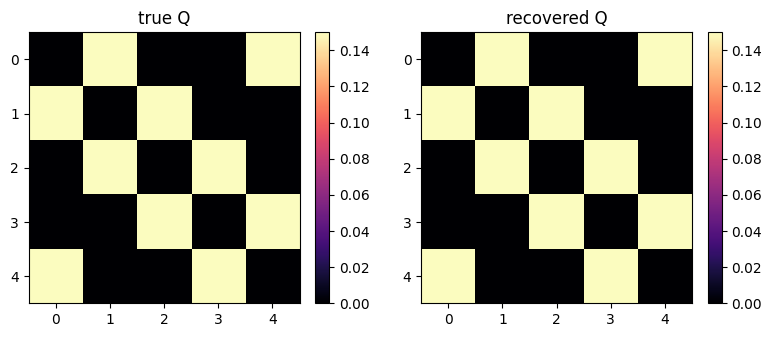

In [2]:
N, n0 = 5, 2
th, rho = 0.6, 0.9                                       # node: stable oscillator, eig rho*e^{+-i th}
A0 = rho * np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
B0 = np.array([[0.0], [1.0]]); C0 = np.array([[1.0, 0.0]])
ring = np.array([[0,1,0,0,1],[1,0,1,0,0],[0,1,0,1,0],[0,0,1,0,1],[1,0,0,1,0]], float)
Q_true = 0.15 * ring                                     # sparse coupling (small => stable)
A, B, C, Acl = homog_network(A0, B0, C0, Q_true)
n = N * n0; r = 2 * n - 1                                # r >= 2n-1 for exact identifiability
M, CAlB = markov_params(A, B, C, Acl, r)
Q_hat = reconstruct_Q(M, CAlB, N, r)
print('closed-loop spectral radius:', round(float(np.max(np.abs(np.linalg.eigvals(Acl)))), 3))
print('reconstruction error ||Q_hat - Q||_F / ||Q||_F =', np.linalg.norm(Q_hat - Q_true) / np.linalg.norm(Q_true))
fig, ax = plt.subplots(1, 2, figsize=(8, 3.4))
for a, (t, Qm) in zip(ax, [('true Q', Q_true), ('recovered Q', Q_hat)]):
    im = a.imshow(Qm, cmap='magma'); a.set_title(t); fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

## 2 · Application to the grid data

Our tensor `H[s,r,t]` gives the closed-loop Markov parameters `M_ℓ[i,j] = H[j,i,ℓ]`. We must **assume** a homogeneous node model (the method needs known nodes): we fit an **AR(2)** to the pooled sign-normalized self-response and use it as the node `(A0,B0,C0)`. Then reconstruct `Q`.

**Reality check printed below:** we have far fewer lags than `2n−1`, so the system is underdetermined and needs ridge regularization — read the reconstruction as *regularized/approximate*, not the paper's exact recovery.

In [3]:
import sys; sys.path.insert(0, '.')          # run from bilateral/grid (or adjust)
import cross_response as cr
z = cr.load_cached(); H, sites, window = z['H'], z['sites'], z['window']; nS = len(sites)
klo = int(np.argmin(np.abs(window - 0.08))); khi = int(np.argmin(np.abs(window - 0.60)))
lags = list(range(klo, khi + 1)); rG = len(lags) - 1
M_data = [H[:, :, l].T.copy() for l in lags]              # closed-loop Markov (empirical), M_0..M_rG
# assume homogeneous node = AR(2) fit of the pooled sign-normalized self-response
sm = np.mean([np.sign(H[s, s, klo]) * H[s, s, klo:khi + 1] for s in range(nS)], 0)
a1, a2 = np.linalg.lstsq(np.column_stack([sm[1:-1], sm[:-2]]), sm[2:], rcond=None)[0]
A0g = np.array([[0, 1], [a2, a1]]); B0g = np.array([[0.], [1.]]); C0g = np.array([[1., 0.]])
Ag, Bg, Cg = np.kron(np.eye(nS), A0g), np.kron(np.eye(nS), B0g), np.kron(np.eye(nS), C0g)
nG = Ag.shape[0]; CAlBg = []; Pg = np.eye(nG)
for _ in range(rG + 1): CAlBg.append(Cg @ Pg @ Bg); Pg = Ag @ Pg
print(f'node AR(2): a1={a1:.3f} a2={a2:.3f} | node |eig| {np.abs(np.linalg.eigvals(A0g)).round(3)}')
print(f'lags available r={rG}  vs  2n-1 = {2*nG-1} needed for exact identifiability  => underdetermined')

node AR(2): a1=1.504 a2=-0.579 | node |eig| [0.761 0.761]
lags available r=36  vs  2n-1 = 207 needed for exact identifiability  => underdetermined


In [4]:
Dm = np.linalg.norm(sites[:, None, :] - sites[None, :, :], axis=2); off = ~np.eye(nS, dtype=bool)
print('ridge      ||Q||    corr(|Q|,distance)   (negative => local coupling)')
Q_by_ridge = {}
for lam in [1e-1, 1e1, 1e3]:
    Qg = reconstruct_Q(M_data, CAlBg, nS, rG, ridge=lam); Q_by_ridge[lam] = Qg
    corr = np.corrcoef(np.abs(Qg)[off], Dm[off])[0, 1]
    print(f'  {lam:<8.0e} {np.linalg.norm(Qg):8.2f}      {corr:+.3f}')

ridge      ||Q||    corr(|Q|,distance)   (negative => local coupling)
  1e-01        9.51      -0.093
  1e+01        0.81      -0.172
  1e+03        0.03      -0.443


### Recovered coupling on the grid (strong-ridge solution)

At strong regularization the recovered `Q` becomes **local** (coupling falls off with distance) and respects the hemispheres — qualitatively the same picture the directed graph-wave gives. Treat this as *corroboration* (two very different methods agree on locality), not an independent result: the locality strengthens exactly as ridge shrinks `Q`, because the raw problem is underdetermined.

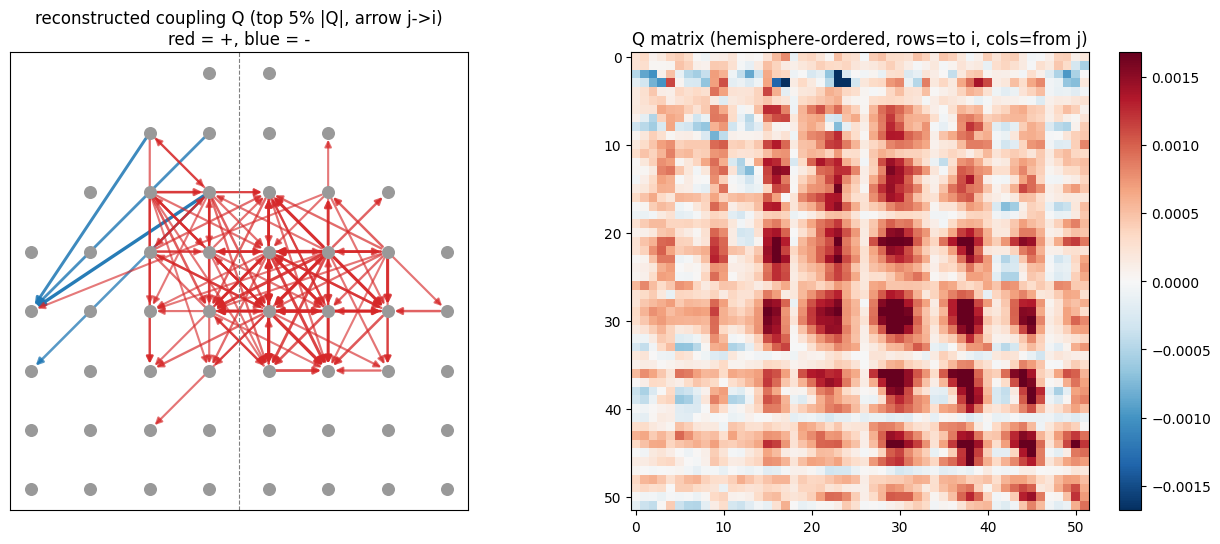

In [5]:
Qg = Q_by_ridge[1e3]
order = np.lexsort((sites[:, 1], sites[:, 0]))
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
a = ax[0]; W = np.abs(Qg); thr = np.percentile(W[W > 0], 95); wmax = W.max()
a.scatter(sites[:, 0], sites[:, 1], c='0.6', s=70, zorder=3)
for i in range(nS):
    for j in range(nS):
        if i != j and W[i, j] >= thr:
            a.annotate('', xy=sites[i], xytext=sites[j], zorder=2,
                       arrowprops=dict(arrowstyle='-|>', lw=0.3 + 2.2 * W[i, j] / wmax,
                                       alpha=min(1.0, 0.15 + 0.85 * W[i, j] / wmax),
                                       color='tab:red' if Qg[i, j] > 0 else 'tab:blue', shrinkA=5, shrinkB=5))
a.axvline(0, color='.5', ls='--', lw=.8); a.set_aspect('equal'); a.set_xticks([]); a.set_yticks([])
a.set_title('reconstructed coupling Q (top 5% |Q|, arrow j->i)\nred = +, blue = -')
a = ax[1]; im = a.imshow(Qg[np.ix_(order, order)], cmap='RdBu_r',
                         vmin=-np.percentile(np.abs(Qg), 98), vmax=np.percentile(np.abs(Qg), 98))
a.set_title('Q matrix (hemisphere-ordered, rows=to i, cols=from j)'); fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

## Verdict — when this method fits, and when ours does

**What the Sylvester method gives (and it's real):** an *exact*, *closed-form (linear)* topology reconstruction with identifiability guarantees — no nonconvex optimization, and each row of `Q` solves independently (parallelizable). Verified to machine precision in §1.

**Why it isn't the primary tool for *this* dataset:**
- It assumes the **node dynamics are known**. Our nodes are cortical pixels whose intrinsic dynamics are entangled with the coupling — we can only *assume* a homogeneous node model, and the result depends on that assumption.
- Exact recovery needs `r ≥ 2n−1` (≈207 lags for 2nd-order nodes); we have ~36. The raw problem is **underdetermined** and blows up without regularization.
- Our **graph-wave** fit (`network_id.py`) is built for exactly the opposite regime: it *jointly* learns node dynamics + a directed/sparse/distance-constrained coupling by simulation error, with no pre-specified node model and no `2n−1`-lag requirement.

**Where it becomes the right tool:** if we run a **persistently-exciting multi-site drive** experiment (long, rich input rather than single-site impulses) and commit to a node model, this method would reconstruct `Q` in closed form with guarantees — a strong future direction. For now it serves as an independent **cross-check**: even under its own assumptions the recovered coupling is local + hemisphere-respecting, agreeing with the graph-wave.